# Исследование надежности заемщиков


### Описание проекта
Заказчик — кредитный отдел банка. Нужно разобраться, влияет ли семейное положение и количество детей клиента на факт погашения кредита в срок. Результаты исследования будут учтены при построении модели кредитного скоринга — специальной системы, которая оценивает способность потенциального заёмщика вернуть кредит банку. 

### Цель исследования

Определить, влияет ли семейное положение и количество детей клиента на факт своевременного возврата кредита.

### План исследования

1. Предобработка данных.
2. Анализ факторов риска.
3. Формулирование выводов и рекомендаций.

### Описание данных 
Входные данные от банка — статистика о платёжеспособности клиентов. 
* children — количество детей в семье 
* days_employed — общий трудовой стаж в днях 
* dob_years — возраст клиента в годах 
* education — уровень образования клиента 
* education_id — идентификатор уровня образования 
* family_status — семейное положение 
* family_status_id — идентификатор семейного положения 
* gender — пол клиента 
* income_type — тип занятости 
* debt — имел ли задолженность по возврату кредитов 
* total_income — ежемесячный доход 
* purpose — цель получения кредита

## Общая информация о данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data.csv')

In [3]:
data.head(20)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,высшее,0,женат / замужем,0,F,сотрудник,0,253875.639453,покупка жилья
1,1,-4024.803754,36,среднее,1,женат / замужем,0,F,сотрудник,0,112080.014102,приобретение автомобиля
2,0,-5623.422610,33,Среднее,1,женат / замужем,0,M,сотрудник,0,145885.952297,покупка жилья
3,3,-4124.747207,32,среднее,1,женат / замужем,0,M,сотрудник,0,267628.550329,дополнительное образование
4,0,340266.072047,53,среднее,1,гражданский брак,1,F,пенсионер,0,158616.077870,сыграть свадьбу
5,0,-926.185831,27,высшее,0,гражданский брак,1,M,компаньон,0,255763.565419,покупка жилья
6,0,-2879.202052,43,высшее,0,женат / замужем,0,F,компаньон,0,240525.971920,операции с жильем
7,0,-152.779569,50,СРЕДНЕЕ,1,женат / замужем,0,M,сотрудник,0,135823.934197,образование
8,2,-6929.865299,35,ВЫСШЕЕ,0,гражданский брак,1,F,сотрудник,0,95856.832424,на проведение свадьбы
9,0,-2188.756445,41,среднее,1,женат / замужем,0,M,сотрудник,0,144425.938277,покупка жилья для семьи


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


## Предобработка данных

### Удаление пропусков

In [5]:
data.isna().sum()

children               0
days_employed       2174
dob_years              0
education              0
education_id           0
family_status          0
family_status_id       0
gender                 0
income_type            0
debt                   0
total_income        2174
purpose                0
dtype: int64

Обработаем пропуски в столбце `total_income`. Он хранит данные о доходах. На сумму дохода сильнее всего влияет тип занятости, поэтому заполнить пропуски в этом столбце нужно медианным значением по каждому типу из столбца `income_type`.

In [6]:
median_data = data.groupby('income_type')['total_income'].transform('median')
median_data

0        142594.396847
1        142594.396847
2        142594.396847
3        142594.396847
4        118514.486412
             ...      
21520    172357.950966
21521    118514.486412
21522    142594.396847
21523    142594.396847
21524    142594.396847
Name: total_income, Length: 21525, dtype: float64

In [7]:
data['total_income'] = data['total_income'].fillna(median_data)

### Обработка аномальных значений

В данных могут встречаться значения, которые не отражают действительность и появились по какой-то ошибке. Например, отрицательное количество дней трудового стажа в столбце `days_employed`. Заменим все отрицательные значения положительными. 

In [8]:
data['days_employed'] = data['days_employed'].abs()
data['days_employed']

0          8437.673028
1          4024.803754
2          5623.422610
3          4124.747207
4        340266.072047
             ...      
21520      4529.316663
21521    343937.404131
21522      2113.346888
21523      3112.481705
21524      1984.507589
Name: days_employed, Length: 21525, dtype: float64

In [9]:
data.groupby('income_type')['days_employed'].median()

income_type
безработный        366413.652744
в декрете            3296.759962
госслужащий          2689.368353
компаньон            1547.382223
пенсионер          365213.306266
предприниматель       520.848083
сотрудник            1574.202821
студент               578.751554
Name: days_employed, dtype: float64

У двух типов (безработные и пенсионеры) получились аномально большие значения. Но по условию задачи оставляем их так, как есть, этот столбец не понадобится для дальнейшего исследования.

In [10]:
data['children'].unique()

array([ 1,  0,  3,  2, -1,  4, 20,  5])

Удалим строки, в которых встречаются аномальные значения по количеству детей. 

In [11]:
data = data[~data['children'].isin([-1,20])]

In [12]:
data['children'].unique()

array([1, 0, 3, 2, 4, 5])

### Удаление пропусков (продолжение)

Заполним пропуски в столбце `days_employed` медианными значениями по каждого типа занятости `income_type`.

In [13]:
median_days_employed = data.groupby('income_type')['days_employed'].transform('median')

data['days_employed'] = data['days_employed'].fillna(median_days_employed)
data['days_employed']

0          8437.673028
1          4024.803754
2          5623.422610
3          4124.747207
4        340266.072047
             ...      
21520      4529.316663
21521    343937.404131
21522      2113.346888
21523      3112.481705
21524      1984.507589
Name: days_employed, Length: 21402, dtype: float64

In [14]:
data.isna().sum()

children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64

### Изменение типов данных

Заменим вещественный тип данных в столбце `total_income` на целочисленный. 

In [15]:
data['total_income'] = data['total_income'].astype(int)

### Обработка дубликатов

In [16]:
data['education'].unique()

array(['высшее', 'среднее', 'Среднее', 'СРЕДНЕЕ', 'ВЫСШЕЕ',
       'неоконченное высшее', 'начальное', 'Высшее',
       'НЕОКОНЧЕННОЕ ВЫСШЕЕ', 'Неоконченное высшее', 'НАЧАЛЬНОЕ',
       'Начальное', 'Ученая степень', 'УЧЕНАЯ СТЕПЕНЬ', 'ученая степень'],
      dtype=object)

Обработаем неявные дубликаты в столбце `education`, приведем написание к нижнему регистру. 

In [17]:
data['education'] = data['education'].str.lower()
data['education']

0         высшее
1        среднее
2        среднее
3        среднее
4        среднее
          ...   
21520    среднее
21521    среднее
21522    среднее
21523    среднее
21524    среднее
Name: education, Length: 21402, dtype: object

Посмотрим на количество строк-дубликатов в данных.

In [18]:
data.duplicated().sum()

np.int64(71)

In [19]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

### Категоризация данных

Создадим  столбец `total_income_category` с категориями на основании диапазонов:

- 0–30000 — `'E'`;
- 30001–50000 — `'D'`;
- 50001–200000 — `'C'`;
- 200001–1000000 — `'B'`;
- 1000001 и выше — `'A'`.

In [20]:
def categorize_income(income):
    if 0 <= income <= 30000:
        return 'E'
    elif 30001 <= income <= 50000:
        return 'D'
    elif 50001 <= income <= 200000:
        return 'C'
    elif 200001 <= income <= 1000000:
        return 'B'
    elif income >= 1000001:
        return 'A'

In [21]:
data['total_income_category'] = data['total_income'].apply(categorize_income)
data['total_income_category']

0        B
1        C
2        C
3        B
4        C
        ..
21520    B
21521    C
21522    C
21523    B
21524    C
Name: total_income_category, Length: 21331, dtype: object

In [22]:
data['purpose'].unique()

array(['покупка жилья', 'приобретение автомобиля',
       'дополнительное образование', 'сыграть свадьбу',
       'операции с жильем', 'образование', 'на проведение свадьбы',
       'покупка жилья для семьи', 'покупка недвижимости',
       'покупка коммерческой недвижимости', 'покупка жилой недвижимости',
       'строительство собственной недвижимости', 'недвижимость',
       'строительство недвижимости', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля',
       'операции с коммерческой недвижимостью',
       'строительство жилой недвижимости', 'жилье',
       'операции со своей недвижимостью', 'автомобили',
       'заняться образованием', 'сделка с подержанным автомобилем',
       'получение образования', 'автомобиль', 'свадьба',
       'получение дополнительного образования', 'покупка своего жилья',
       'операции с недвижимостью', 'получение высшего образования',
       'свой автомобиль', 'сделка с автомобилем',
       'профильное образование', 'высшее об

Напишем функцию, которая на основании данных из столбца `purpose` сформирует `purpose_category`, в который войдут следующие категории:

- `'операции с автомобилем'`,
- `'операции с недвижимостью'`,
- `'проведение свадьбы'`,
- `'получение образования'`.

In [23]:
def categorize_purpose(purpose_data):
    if 'авто' in purpose_data:
        return 'операции с автомобилем'
    if ('недвижимост' in purpose_data) or ('жиль' in purpose_data):   
        return 'операции с недвижимостью'
    if 'свадьб' in purpose_data:
        return 'проведение свадьбы'
    if 'образовани' in purpose_data:
        return 'получение образования'

In [24]:
data['purpose_category'] = data['purpose'].apply(categorize_purpose)
data['purpose_category'].unique()

array(['операции с недвижимостью', 'операции с автомобилем',
       'получение образования', 'проведение свадьбы'], dtype=object)

## Исследование данных

#### Есть ли зависимость между количеством детей и возвратом кредита в срок?

In [25]:
data.groupby('children')['debt'].agg(['mean', 'count'])

,mean,count
children,,
0,0.075438,14091
1,0.092346,4808
2,0.094542,2052
3,0.081818,330
4,0.097561,41
5,0.000000,9


В данной выборке мало клиентов, у которых больше двух детей. Для проведения адекватного сравнения данных между разными группами, мы можем объединить семьи с тремя и более детьми, с семьями, в которых два ребёнка. Таким образом, мы разделим всех клиентов на *три основные группы*: без детей, с 1 ребёнком и многодетных.

In [26]:
data['children_group'] = data['children'].apply(lambda x: '0' if x == 0 else '1' if x == 1 else '2+')
data['children_group'].unique()

array(['1', '0', '2+'], dtype=object)

In [27]:
children_group_table = data.groupby('children_group')['debt'].agg(['mean', 'count']).round(3).reset_index()
children_group_table.columns = ['children_category', 'share_with_debt', 'number_of_borrowers']

children_group_table

,children_category,share_with_debt,number_of_borrowers
0,0,0.075,14091
1,1,0.092,4808
2,2+,0.093,2432


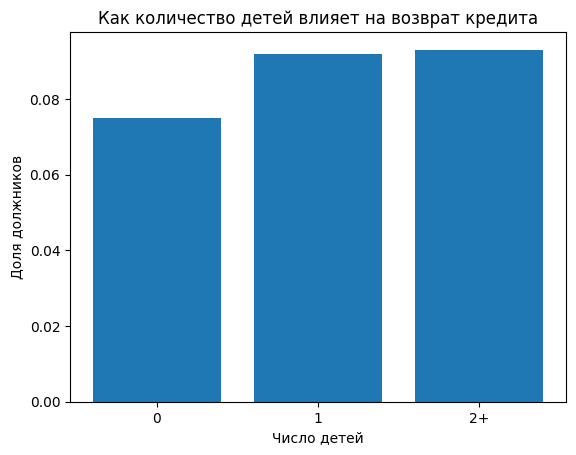

In [28]:
plt.bar(children_group_table['children_category'], children_group_table['share_with_debt'])

plt.title('Как количество детей влияет на возврат кредита')
plt.xlabel('Число детей')
plt.ylabel('Доля должников')
plt.show()

В исследуемой выборке доля задолженностей выше среди клиентов с детьми по сравнению с клиентами без детей. Однако результаты показывают корреляцию и не позволяют утверждать наличие прямой причинно-следственной связи.

#### Есть ли зависимость между семейным положением и возвратом кредита в срок?

In [29]:
def pivot_table_creation(data, index, values):
    table = data.pivot_table(index=index, values=values, aggfunc=['mean', 'count'])\
                         .round(3)\
                         .reset_index()
    
    table.columns = [index, 'share_with_debt', 'number_of_borrowers']
    return table

In [30]:
family_status_data = pivot_table_creation(data, 'family_status', 'debt')
family_status_data

,family_status,share_with_debt,number_of_borrowers
0,Не женат / не замужем,0.098,2796
1,в разводе,0.071,1189
2,вдовец / вдова,0.066,951
3,гражданский брак,0.093,4134
4,женат / замужем,0.076,12261


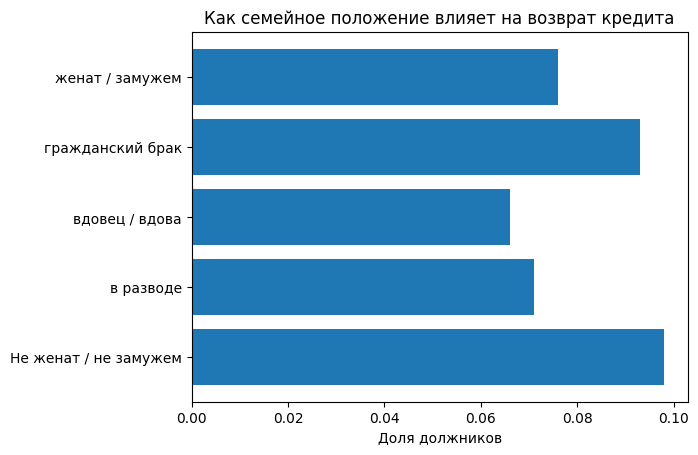

In [31]:
plt.barh(family_status_data['family_status'],
        family_status_data['share_with_debt'])

plt.title('Как семейное положение влияет на возврат кредита')
plt.xlabel('Доля должников')
plt.show()


Среди клиентов, состоящих в официальном браке, доля задолженностей ниже, чем среди клиентов в гражданском браке и не состоящих в отношениях.

#### Есть ли зависимость между уровнем дохода и возвратом кредита в срок?

In [32]:
income_data = pivot_table_creation(data, 'total_income_category', 'debt')
income_data

,total_income_category,share_with_debt,number_of_borrowers
0,A,0.080,25
1,B,0.071,5014
2,C,0.085,15921
3,D,0.060,349
4,E,0.091,22


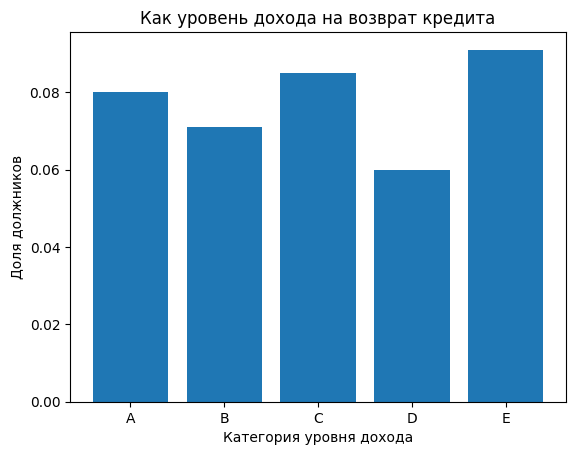

In [33]:
plt.bar(income_data['total_income_category'], income_data['share_with_debt'])
plt.title('Как уровень дохода на возврат кредита')
plt.xlabel('Категория уровня дохода')
plt.ylabel('Доля должников')
plt.show()

Чаще всего задолженности по возврату кредитов возникают у клиентов из категорий E и С. Наименьший процент должников отмечается среди клиентов из категорий B и D. Из графика, представленного выше, можно заключить, что группа клиентов с более высоким ежемесячным доходом чаще выплачивает кредиты в срок. 

Однако нельзя делать однозначные выводы о наличии прямой зависимости между ежемесячным доходом и своевременным возвратом кредита, поскольку категории A, D и E представлены небольшим количеством наблюдений и выводы по ним статистически менее надёжны. 

#### Как разные цели кредита влияют на его возврат в срок?

In [34]:
purpose_data = pivot_table_creation(data, 'purpose_category', 'debt')
purpose_data

,purpose_category,share_with_debt,number_of_borrowers
0,операции с автомобилем,0.093,4279
1,операции с недвижимостью,0.073,10751
2,получение образования,0.093,3988
3,проведение свадьбы,0.079,2313


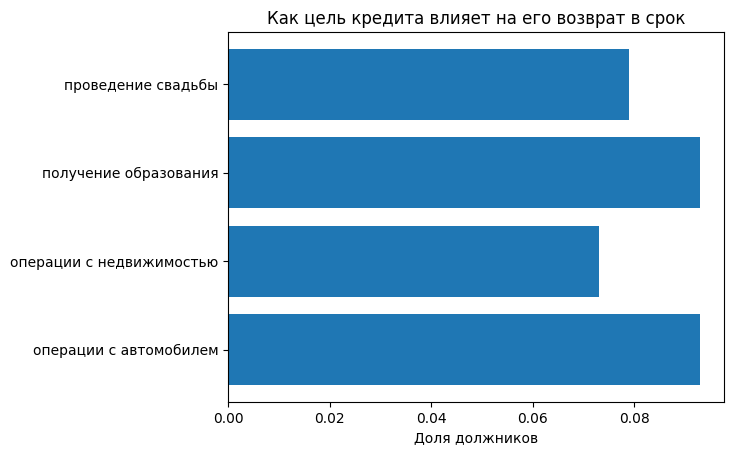

In [35]:
plt.barh(purpose_data['purpose_category'], purpose_data['share_with_debt'])
plt.title('Как цель кредита влияет на его возврат в срок')
plt.xlabel('Доля должников')
plt.show()

Клиенты с кредитами на образование или приобретение автомобиля чаще имеют задолженности по кредитам, чем клиенты, оформляющие кредиты для операций с недвижимостью или проведением свадьбы.

#### Возможные причины появления пропусков в исходных данных

- технические, например, неудачно написанный код для загрузки/выгрузки данных с сервера;
- неправильный запрос, объединение таблиц;
- человеческий фактор при сборе и заполнении информации о клиентах;
- личные цели клиентов банка, которые умышленно оставили пропуски при заполнении анкеты;
- данная информация может не требоваться при заполнении анкет. 

#### Почему заполнить пропуски медианным значением — лучшее решение для количественных переменных

Поскольку переменные `days_employed` и `total_income` являются количественными, наиболее подходящими методами для заполнения пропусков являются среднее арифметическое и медиана. Учитывая наличие выбросов в данных, более корректным выбором будет использование медианы, поскольку среднее арифметическое более чувствительно к воздействию выбросов. 

## Общий вывод


У клиентов банка, у которых нет детей, риск невыплаты кредита ниже. Также клиенты, находящиеся в официальном браке, реже имеют задолженности, чем неженатые/незамужние клиенты. Доля должников среди разведённых клиентов и вдовцов/вдов тоже невелика.

Клиенты с ежемесячным доходом от 200001 до 1000000 рублей (категория 'B') реже становятся должниками по сравнению с клиентами из категории 'C' с заработком от 50001 до 200000 рублей. Однако, данные по другим категориям дохода недостаточны для оценки полной картины взаимосвязи доходов и риска невыплаты кредитов.

Процент должников, оформляющих кредиты для операций с недвижимостью и свадьбы, меньше, чем среди клиентов, берущих кредиты на образование и покупку автомобиля.

Полученные результаты показывают, что семейное положение, наличие детей и цель кредита могут быть использованы в качестве дополнительных факторов при оценке кредитного риска.